In [2]:
from pandas import read_csv

path_to_your_csv ='../../cbsa_sample_data/plants_16980.txt'
crs_of_your_csv =  "EPSG:4326"
pts1 = read_csv(path_to_your_csv, sep=",", header=None)#[:5000]
pts1.columns = ["eid", "employment", "industry", "lat","lon","moved"]



In [114]:
i, selected_row_indices = 0, [7282,83327,58464,6981,84846,40394,29952,42885,6459,974,6058,73784,6615,3780,94210,20156,4348,23058,22862,25254,64620,39456,9975,63271,45368,4980,808,4975,3706,2828,908,74442,1310,3380,6359,1036,77440,7132,9539,1438,26147,39116,1147,22,39229,77821,91638,12787,5733,25149,37158,65437,82287,89828,17250,28474,54052,67185,86807,5764,68178,21569,99033,60437,302,62138,60224,2531,41754,22801,7329,22647,14242,45757,92658,2539,9146,6236,447,3919,45300,12416,13285,25185,2,11653,76227,48499,36613,6364,8678,98689,1435,8423,35725,32432,6394,34589,93593,58704,6331,7350,17868,86401,2816,73074,56203,64808,10420,16530,21602,65143,133,5649]

Reproject from EPSG:4326 to EPSG:32616


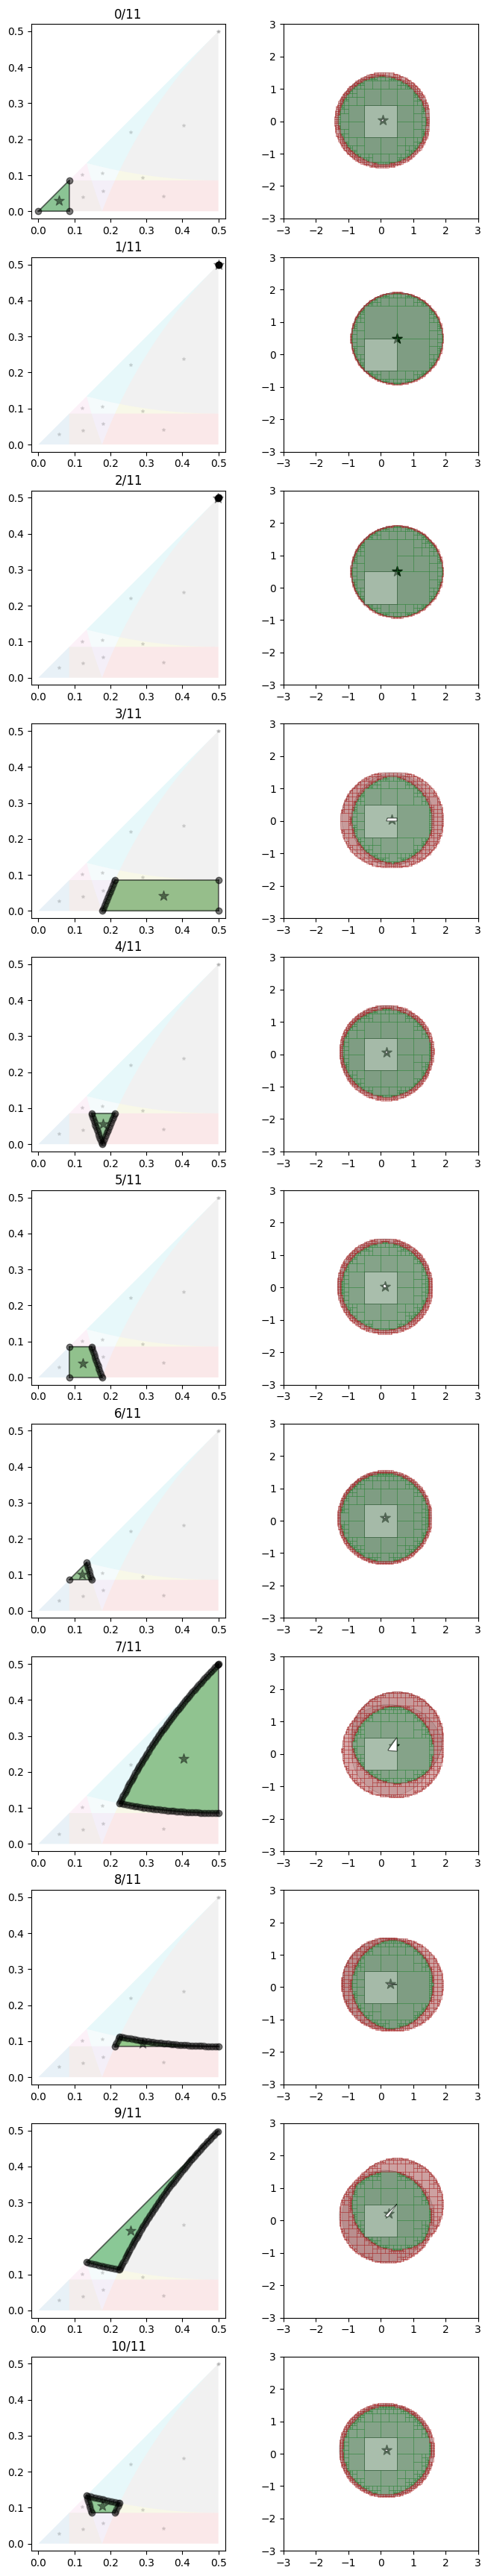

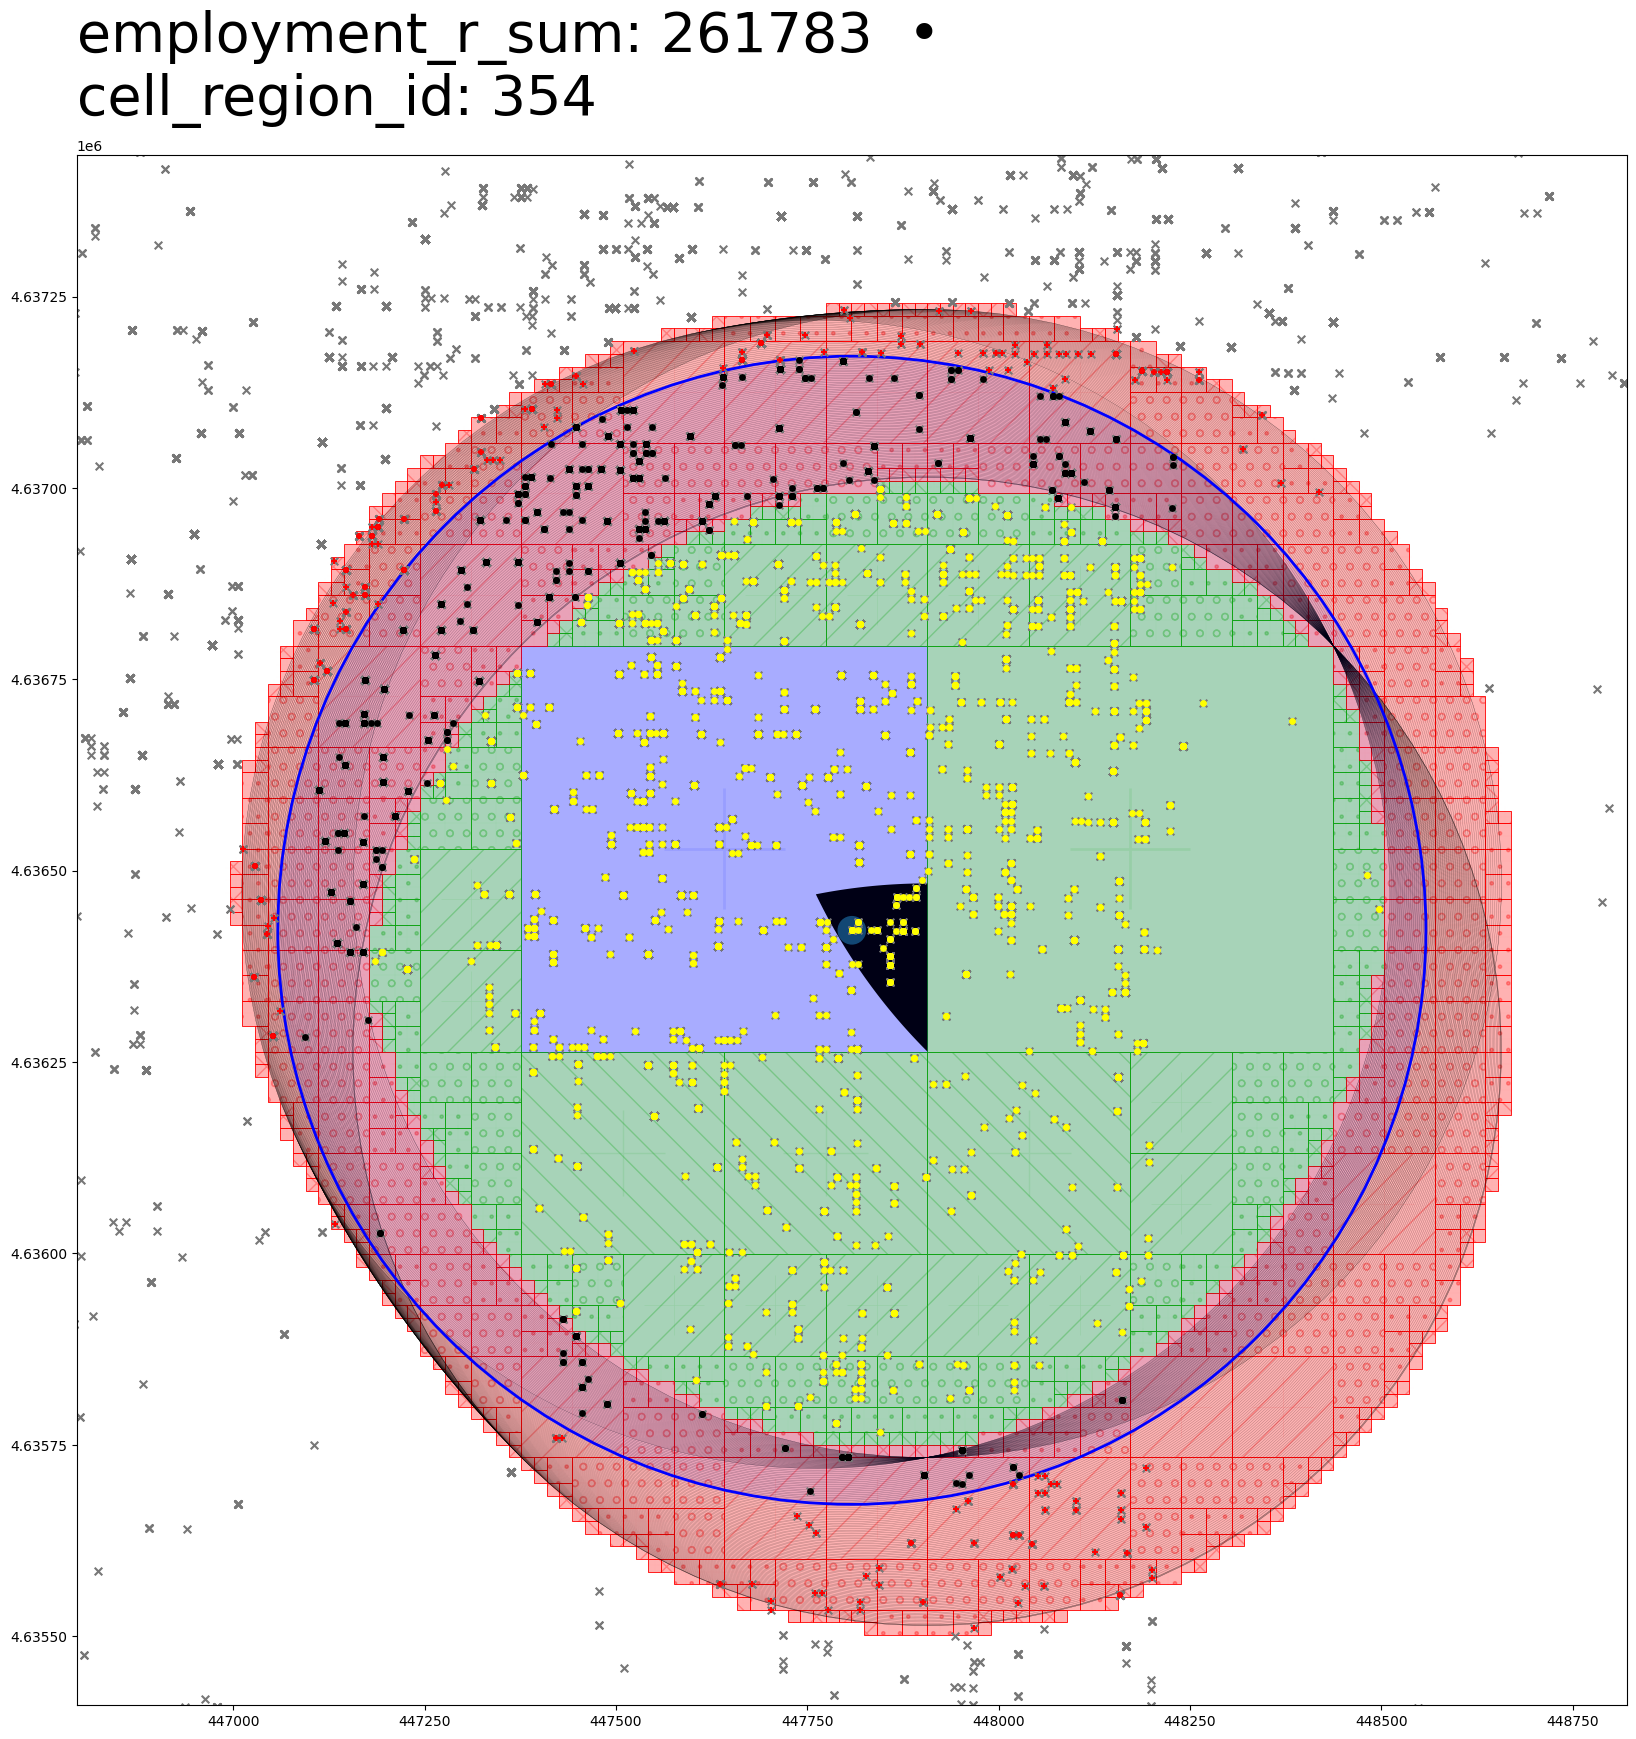

In [3]:
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
from aabpl import radius_search, detect_cluster_pts, detect_cluster_cells, Grid
from aabpl.testing.test_performance import analyze_func_perf, func_timer_dict, reset_perf_times

# reset_perf_times()
r=750
spacing=750/2**.5-0.001
grid = radius_search(
    pts=pts1,
    crs=crs_of_your_csv,
    r=r,
    c='employment',
    exclude_pt_itself=True,
    silent=True,
    # grid=grid_m,
    spacing=spacing,
    nest_depth=5,
    trynew = 2,
    _dev={'plot_pt_disk':{'pt_id':32553}, 'plot_offset_regions':{}},#32553-3
)
# perf_analysis = analyze_func_perf(plot=True)


In [5]:
r=750
spacing=750/2**.5-0.001
grid = radius_search(
    pts=pts1,
    crs=crs_of_your_csv,
    r=r,
    c='employment',
    exclude_pt_itself=True,
    silent=True,
    # grid=grid_m,
    spacing=spacing,
    nest_depth=4,
    trynew = 2,
    # _dev={'plot_pt_disk':{'pt_id':32553}, 'plot_offset_regions':{}},#32553-3
)
# perf_analysis = analyze_

Reproject from EPSG:4326 to EPSG:32616


In [38]:
import sys
import pickle
from aabpl import config
# Quick shallow size (bytes)
# sys.getsizeof(config.disk_region_cache)

# Deep size including all referenced objects
len(pickle.dumps(config.disk_region_cache))


from pympler import asizeof
asizeof.asizeof(config.disk_region_cache)/1024**2
# per entry
for k, v in config.disk_region_cache.items():
    print(k,asizeof.asizeof(v)/1024**2, type(v))
    # for key, val in v[8].items():
    #     print()
    for k0,x in v.items():

        print(type(x), asizeof.asizeof(x)/1024**2,round(asizeof.asizeof(x)/asizeof.asizeof(v),2))

(1.4142162290447902, 5, False) 15.984893798828125 <class 'dict'>
<class 'dict'> 0.0554351806640625 0.0
<class 'dict'> 0.05387115478515625 0.0
<class 'list'> 0.0008697509765625 0.0
<class 'list'> 0.0008697509765625 0.0
<class 'int'> 3.0517578125e-05 0.0
<class 'dict'> 0.0183563232421875 0.0
<class 'dict'> 0.0781707763671875 0.0
<class 'dict'> 0.00565338134765625 0.0
<class 'set'> 0.00034332275390625 0.0
<class 'int'> 3.0517578125e-05 0.0
<class 'dict'> 4.9295806884765625 0.31
<class 'dict'> 8.229141235351562 0.51
<class 'dict'> 5.2138824462890625 0.33
<class 'dict'> 8.229141235351562 0.51


---
## Performance Benchmarking

### Phase 1 — Sweep over optimization parameters

Run `radius_search` for every combination of `(radius, spacing, nest_depth, trynew)`.
Each completed run is saved immediately as a JSON file in `perf_test/`, so the sweep
is restartable and skips already-completed configurations.

**Scenario parameters** (the inputs you cannot choose):
- `search_radius` — the search radius
- point-cloud geometry captured by `calc_distribution_stats`

**Optimization parameters** (what we want to choose optimally):
- `spacing` — grid cell width (chosen from `generate_2d_breakpoints`)
- `nest_depth` — integer 0–9
- `trynew` — algorithm variant 0–3 (Phase 1 only; fixed after first sweep)

**Derived meta-parameters** captured per run:
- `calc_micro_region_stats` — average contained/overlapped cells per region  
  (depends only on the `radius/spacing` ratio, so reusable across point clouds)

In [25]:
path_to_csv = '../../cbsa_sample_data/plants_10180.txt'
crs = "EPSG:4326"
local_crs = 'EPSG:32616'
pts = read_csv(path_to_csv, sep=",", header=None)
pts.columns = ["eid", "employment", "industry", "lat", "lon", "moved"]
len(pts)

15161

In [2]:
# ── Phase 1 Setup ──────────────────────────────────────────────────────────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import os
import numpy as np
from pandas import read_csv
from aabpl.radius_search.grid_class import compute_spacing_breakpoints, compute_spatial_stats
from aabpl.testing.perf_benchmark import run_sweep, candidate_spacings_from_radius, load_results



# ── Data ───────────────────────────────────────────────────────────────────
path_to_csv = '../../cbsa_sample_data/plants_16980.txt'
# path_to_csv = '../../cbsa_sample_data/plants_10180.txt'
crs = "EPSG:4326"
local_crs = 'EPSG:32616'
pts = read_csv(path_to_csv, sep=",", header=None)
pts.columns = ["eid", "employment", "industry", "lat", "lon", "moved"]
pts = pts[:200_00]
# if True: 
#   N = 1_000_000
#   pts = pts.loc[pts.index.repeat(-int(-len(pts)//N))].reset_index(drop=True)[:N]


# if True:
#   lat_min, lat_max = pts["lat"].min(), pts["lat"].max()
#   lon_min, lon_max = pts["lon"].min(), pts["lon"].max()

#   rng = np.random.default_rng(42)
#   pts["lat"] = rng.uniform(lat_min, lat_max, len(pts))
#   pts["lon"] = rng.uniform(lon_min, lon_max, len(pts))



# ── Scenario parameters ────────────────────────────────────────────────────
# Multiple radii let us see how the optimum shifts with search radius
SAMPLE_SIZES = [80_000] #[1_000, 100_000, 10]
RADII = [750, 15_000, 75]           # metres — adjust to your use case

# ── Optimization parameter grid ────────────────────────────────────────────
# Spacings: the canonical breakpoints for each radius (r / breakpoint_ratio)
# Use the same breakpoints for all radii so results are comparable.
_bp_ratios = compute_spacing_breakpoints(max_offset=4) 
  # topological breakpoints
# break_points = _np_array([
#               2**.5, 1.5, 2.5**.5, 2, 4.5**0.5, 5**0.5, 2.5, 
#               (13/2)**0.5,(17/2)**0.5, 
#               # 7/2, (25/2)**0.5, 	13**0.5, (29/2)**0.5
#               ])
SPACING_RATIOS = [2**.5, 1.5, 2.5**.5, 2, 4.5**0.5, 5**0.5, 2.5 ][3:]
# list(set(
#     r / ratio
#     for r in RADII
#     for ratio in _bp_ratios[[1,2,3,6,10]] # [1.5, 1.58113883, 2. , 2.5, 3. , 4. ]
#     if r / ratio >= 50              # ignore extremely fine grids
# ))
print(f"{len(SPACING_RATIOS)} candidate SPACING_RATIOS: {SPACING_RATIOS[:10]} ...")

NEST_DEPTHS = [0, 1, 2, 3, 4, 5][-1:]  #[4,5]      # extend to 0–9 once Phase 1 is feasible
TRYNEWS     = [0, 1]        # all four variants in Phase 1

# ── Output folder ─────────────────────────────────────────────────────────
PERF_FOLDER = os.path.join(".", "perf_test")
os.makedirs(PERF_FOLDER, exist_ok=True)
print(f"Results will be saved to: {os.path.abspath(PERF_FOLDER)}")
print(f"Total combinations: {len(RADII)} radii × {len(SPACING_RATIOS)} SPACING_RATIOS × "
      f"{len(NEST_DEPTHS)} nest_depths × {len(TRYNEWS)} trynews "
      f"= {len(RADII)*len(SPACING_RATIOS)*len(NEST_DEPTHS)*len(TRYNEWS)}")

4 candidate SPACING_RATIOS: [2, 2.1213203435596424, 2.23606797749979, 2.5] ...
Results will be saved to: z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test
Total combinations: 3 radii × 4 SPACING_RATIOS × 1 nest_depths × 2 trynews = 24


### Phase 1 Analysis — explore timing landscape

In [ ]:
# ── Phase 1: Run sweep ─────────────────────────────────────────────────────
# Each completed run is saved immediately; rerunning this cell skips finished ones.
sweep_df = run_sweep(
    pts=pts,
    crs=crs,
    radii=RADII,
    spacing_ratios=SPACING_RATIOS,
    sample_sizes=SAMPLE_SIZES,
    nest_depths=NEST_DEPTHS,
    trynews=TRYNEWS,
    col="employment",
    local_crs=local_crs,
    output_folder=PERF_FOLDER,
    silent=None,
    skip_existing=True,
    verbose=True,
    top_k=9,
)
print(f"\nSweep complete. {len(sweep_df)} runs collected.")
sweep_df.head()


=== Phase 1: screening 210 configs with 2,000 source points ===
  [>                 ]   0%  1/210  run   r=750 sr=1.41 nd..    0.0s  ~0s left            Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   0%  2/210  run   r=750 sr=1.41 nd..    37.9s  ~3945s left        s  ~103s left  Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   1%  3/210  run   r=750 sr=1.41 nd..    42.6s  ~2942s left          ~11s left   Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   1%  4/210  run   r=750 sr=1.41 nd..    80.5s  ~4148s left        s  ~103s left  Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   2%  5/210  run   r=750 sr=1.41 nd..    85.3s  ~3499s left          ~12s left   Create grid with 133*133=17689 with spacing 530.3300858899106
  [>                 ]   2%  6/210  run   r=750 sr=1.41 nd..    123.4s  ~4197s left       s  ~103s left  Create grid 

In [ ]:
import os
print(os.path.abspath("./perf_test"))

z:\Algorithm\PL_python\AABPL-toolkit-python\perf_test


### Phase 2 — Predictor

After Phase 1 we fix `trynew` to the best variant and fit a predictor that maps
`(scenario_stats, micro_region_stats, spacing, nest_depth)` → `predicted_cpu_time`.

Key insight: `micro_region_stats` depend only on the `radius/spacing` ratio (pure
geometry), so the model can reuse those values across entirely different point clouds
without re-running the algorithm — enabling fast optimum-finding for new datasets.

In [9]:
# ── Load all saved results (safe to run even if sweep ran in multiple sessions) ─
df = load_results(PERF_FOLDER)
print(f"Total runs loaded: {len(df)}")
print(f"Columns: {list(df.columns)}\n")

# Best config per radius
if "total_cpu_s" in df.columns and "radius" in df.columns:
    best = (
        df.sort_values("total_cpu_s")
        .groupby("radius")
        .first()[["spacing", "nest_depth", "trynew", "total_cpu_s"]]
    )
    print("Best config per radius (lowest CPU time):")
    print(best.to_string())

Total runs loaded: 1516
Columns: ['_source_file', 'scenario_id', 'timestamp', 'machine_id', 'machine_hostname', 'machine_os', 'machine_os_version', 'machine_cpu', 'machine_cpu_count', 'machine_ram_gb', 'machine_python', 'machine_machine_id', 'radius', 'spacing', 'radius_over_spacing', 'nest_depth', 'trynew', 'col', 'n_source', 'n_target', 'geometry_cached', 'scen_spatial_width', 'scen_spatial_height', 'scen_spatial_area', 'scen_spatial_aspect_ratio', 'scen_ratio_radius_to_world', 'scen_boundary_overhead_factor_radius', 'scen_density_skewness_max_to_mean', 'scen_density_max_target_points_in_test_cell', 'scen_total_target_points', 'scen_clumping_floor_median', 'scen_clumping_floor_percentile_5', 'total_cpu_s', 'total_wall_s', 'func_Grid.__init__', 'func_radius_search', 'func_DiskSearch.__init__', 'func_update_search_params', 'func_gen_weak_order_rel_to_convex_set', 'func_create_bilateral_comp_mx_smaller_than', 'func_add_attributes_to_tree', 'func_set_target', 'func_DiskSearchTarget.__ini

In [ ]:
# ── Phase 2: Fix trynew ────────────────────────────────────────────────────
# After inspecting the heatmaps above, pick the best trynew variant.
# Set BEST_TRYNEW = None to keep all variants in the predictor training data.
BEST_TRYNEW = None   # e.g. set to 1 once Phase 1 confirms variant 1 is fastest

train_df = df.copy()
if BEST_TRYNEW is not None:
    train_df = train_df[train_df["trynew"] == BEST_TRYNEW]
print(f"Training rows: {len(train_df)}")

# ── Fit predictor ──────────────────────────────────────────────────────────
from aabpl.testing.perf_benchmark import build_predictor, recommend_config, FEATURE_COLS

predictor_fn, model, used_features = build_predictor(train_df)
print(f"Predictor trained on features: {used_features}")

# Quick in-sample check
import numpy as np
preds = predictor_fn(train_df)
resid = train_df["total_cpu_s"].values - preds
print(f"In-sample MAE: {np.abs(resid).mean():.3f}s  |  R²: {1 - np.var(resid)/np.var(train_df['total_cpu_s']):.3f}")
train_df['search_cpu_s'] = train_df['total_cpu_s'] - train_df['func_build_disk_region_lookups'].fillna(0)

Training rows: 1301
Predictor trained on features: ['scen_spatial_width', 'scen_spatial_height', 'scen_spatial_area', 'scen_spatial_aspect_ratio', 'scen_density_skewness_max_to_mean', 'scen_total_target_points', 'scen_clumping_floor_median', 'radius_over_spacing', 'nest_depth']
In-sample MAE: 13.212s  |  R²: 0.326


In [ ]:
cold = train_df[~train_df['geometry_cached']]   # paid build cost
warm = train_df[train_df['geometry_cached']]    # geometry was free

# e.g. cost = a * n_source * (r/s)^b * nest_depth_factor[nd]
# fit a, b, and per-nd factors via log-linear regression
import numpy as np
from sklearn.linear_model import LinearRegression

df = warm.copy()  # use cached runs only — pure search time
df['log_cost'] = np.log(df['search_cpu_s'])
df['log_n'] = np.log(df['n_source'])
df['log_ros'] = np.log(df['radius_over_spacing'])
# one-hot nest_depth or log(nd+1)

In [ ]:
[c for c in train_df.columns if 'aggregate' in c]

['func_aggregate_point_data_to_cells',
 'func_search_and_aggregate',
 'aggregate_cpu_s']

radius_over_spacing                  0.266123
scen_spatial_area                    0.248501
scen_spatial_aspect_ratio            0.155965
nest_depth                           0.127984
scen_spatial_height                  0.090820
scen_spatial_width                   0.038622
scen_clumping_floor_median           0.038235
scen_total_target_points             0.025008
scen_density_skewness_max_to_mean    0.008741
dtype: float64
{'alpha': 0.9, 'ccp_alpha': 0.0, 'criterion': 'deprecated', 'init': None, 'learning_rate': 0.1, 'loss': 'squared_error', 'max_depth': 4, 'max_features': None, 'max_leaf_nodes': None, 'min_impurity_decrease': 0.0, 'min_samples_leaf': 1, 'min_samples_split': 2, 'min_weight_fraction_leaf': 0.0, 'n_estimators': 200, 'n_iter_no_change': None, 'random_state': 42, 'subsample': 1.0, 'tol': 0.0001, 'validation_fraction': 0.1, 'verbose': 0, 'warm_start': False}


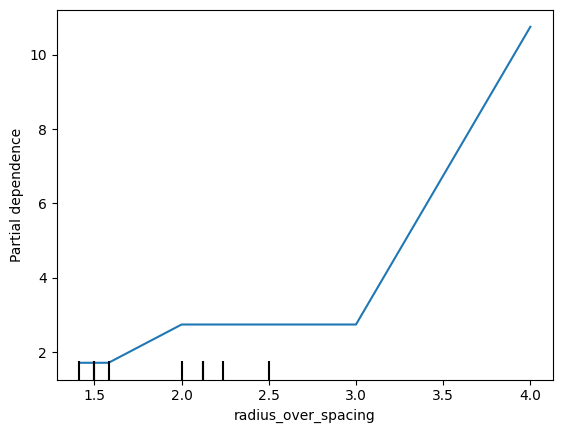

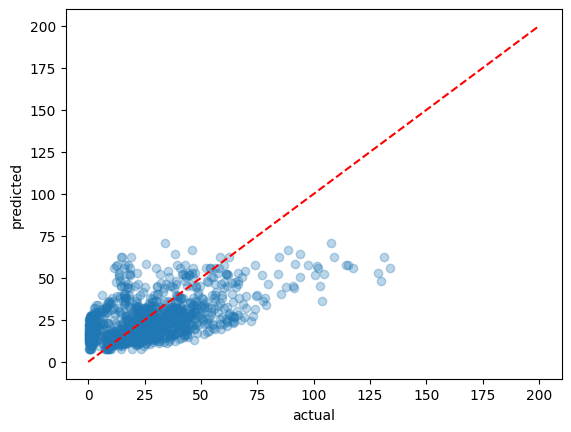

In [ ]:
# Get the fitted model out of the pipeline
gbr = model.named_steps['mdl']

# Feature importances
import pandas as pd
importances = pd.Series(gbr.feature_importances_, index=used_features).sort_values(ascending=False)
print(importances)

# How many trees, depth, etc.
print(gbr.get_params())

# Partial dependence for a single feature (e.g. radius_over_spacing)
from sklearn.inspection import PartialDependenceDisplay
import matplotlib.pyplot as plt
PartialDependenceDisplay.from_estimator(gbr, train_df[used_features].dropna(), ['radius_over_spacing'])
plt.show()

# Actual vs predicted scatter
preds = model.predict(train_df[used_features])
plt.scatter(train_df['total_cpu_s'], preds, alpha=0.3)
plt.xlabel('actual'); plt.ylabel('predicted'); plt.plot([0,200],[0,200],'r--')
plt.show()

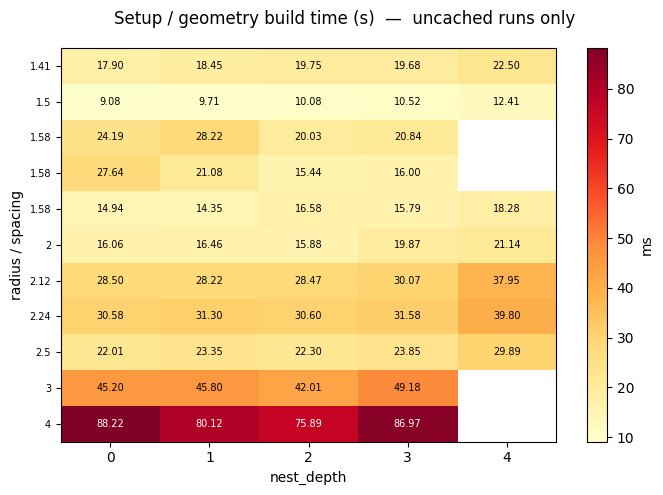

440


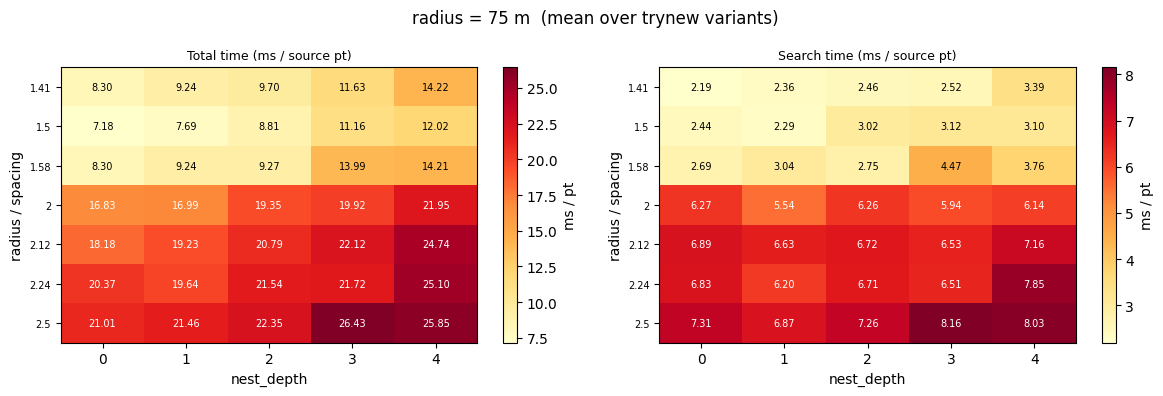

598


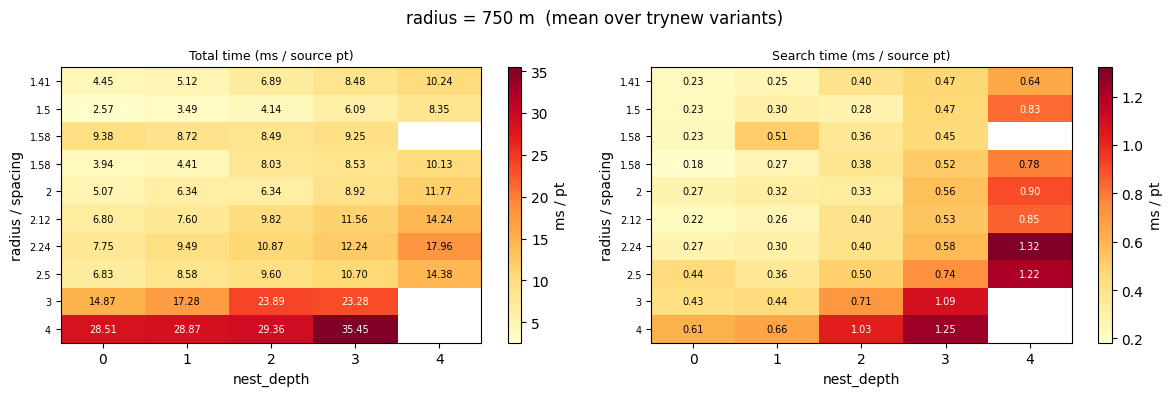

478


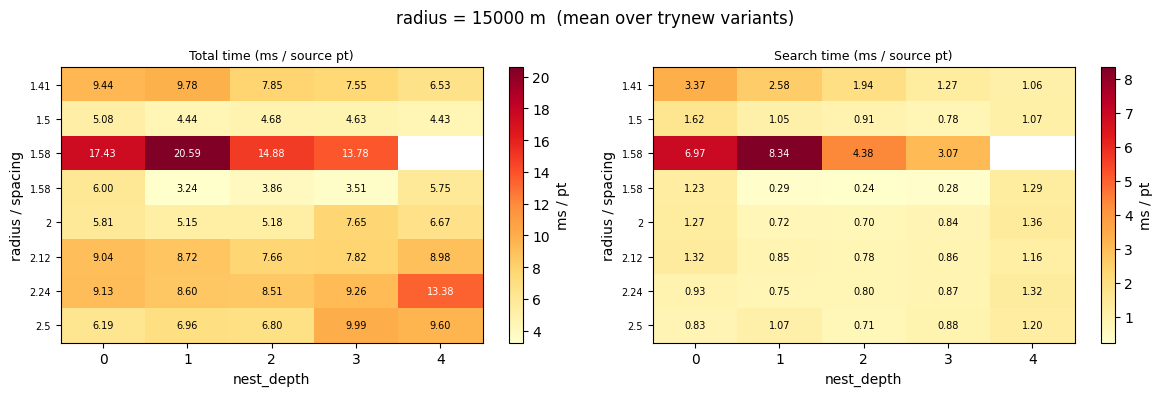


Mean ms/pt by trynew:
        total_ms_per_pt  setup_ms_per_pt  search_ms_per_pt
trynew                                                    
0                16.513           22.079             2.119
1                 4.844            2.786             1.812


In [11]:
import matplotlib.pyplot as plt
import numpy as np

# derived per-point metrics
df["total_ms_per_pt"]  = df["total_cpu_s"] / df["n_source"] * 1000
df["setup_ms_per_pt"]  = df.get("func_build_disk_region_lookups", 0)
df["search_ms_per_pt"] = df.get("func_search_and_aggregate", 0) / df["n_source"] * 1000

df_uncached = df[df["geometry_cached"] == False]

VARIANTS = [
    ("total_ms_per_pt",  "Total time (ms / source pt)"),
    ("search_ms_per_pt", "Search time (ms / source pt)"),
]

# ── geometry build time: one plot, not per radius ────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
fig.suptitle("Setup / geometry build time (s)  —  uncached runs only", fontsize=12)

if not df_uncached.empty:
    piv = (
        df_uncached.groupby(["radius_over_spacing", "nest_depth"])["setup_ms_per_pt"]
        .mean()
        .unstack("nest_depth")
    )
    vals = piv.values.astype(float)
    if vals.size > 0 and not np.all(np.isnan(vals)):
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        plt.colorbar(im, ax=ax, label="ms")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")
    else:
        ax.set_title("(no uncached data)")
else:
    ax.set_title("(no uncached data)")

plt.tight_layout()
plt.show()

# ── per-radius plots ─────────────────────────────────────────────────────────
for r in sorted(df["radius"].unique()):
    sub = df[df["radius"] == r]
    if sub.empty:
        continue

    print(len(sub))
    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    fig.suptitle(f"radius = {r} m  (mean over trynew variants)", fontsize=12)

    for ax, (metric, title) in zip(axes, VARIANTS):
        piv = (
            sub.groupby(["radius_over_spacing", "nest_depth"])[metric]
            .mean()
            .unstack("nest_depth")
        )
        vals = piv.values.astype(float)
        if vals.size == 0 or np.all(np.isnan(vals)):
            ax.set_title(f"{title}\n(no data)", fontsize=9)
            continue
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, label="ms / pt")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")

    plt.tight_layout()
    plt.show()

# ── trynew comparison ────────────────────────────────────────────────────────
if "trynew" in df.columns:
    print("\nMean ms/pt by trynew:")
    print(df.groupby("trynew")[["total_ms_per_pt", "setup_ms_per_pt", "search_ms_per_pt"]]
          .mean().round(3).to_string())

166


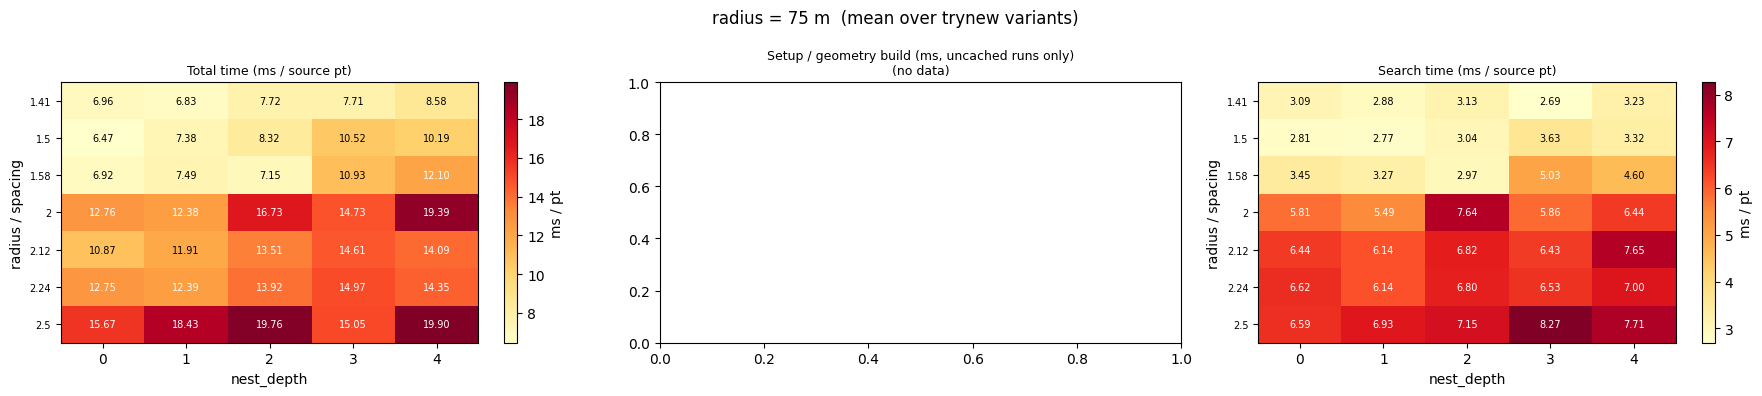

241


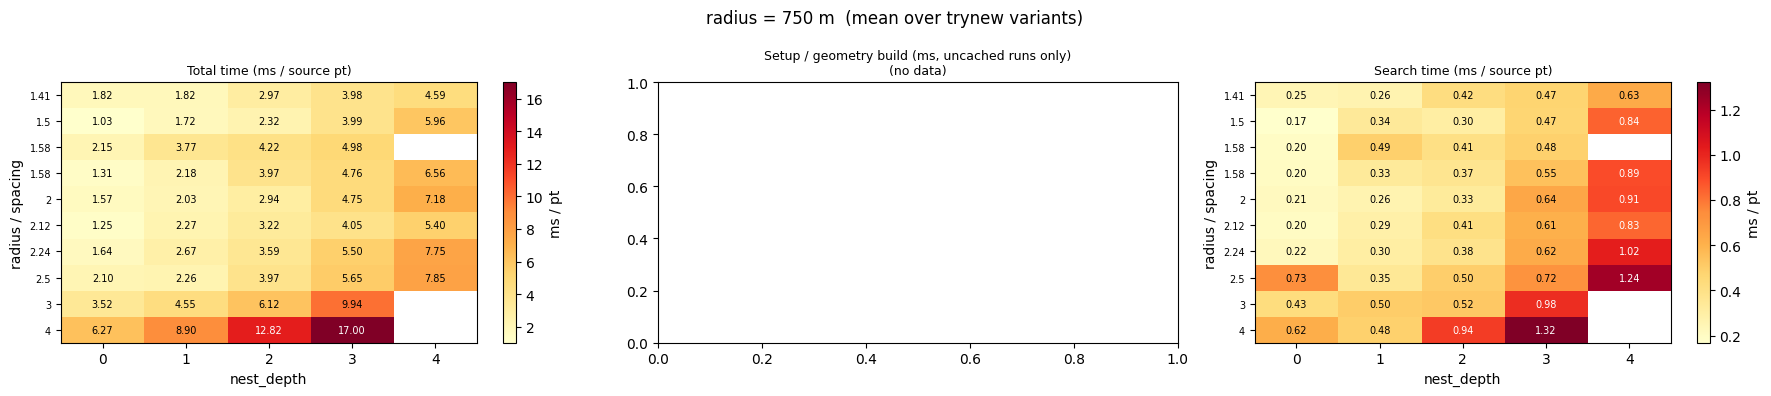

189


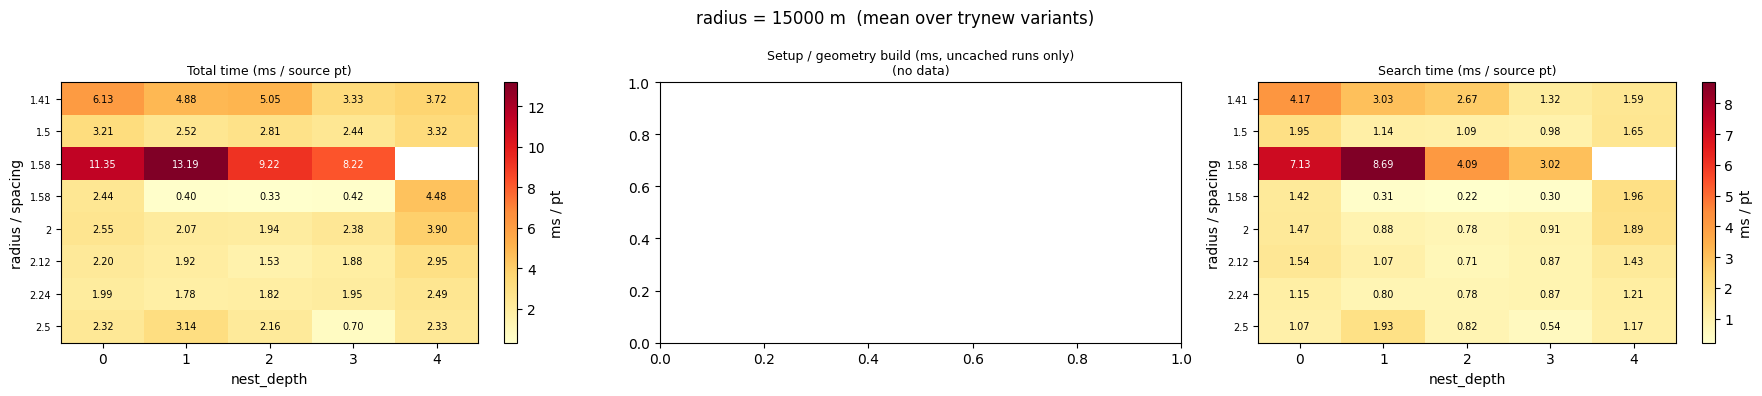


Mean ms/pt by trynew:
        total_ms_per_pt  setup_ms_per_pt  search_ms_per_pt
trynew                                                    
0                 5.871            1.736             1.980
1                 5.668            0.106             2.091


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# derived per-point metrics
df["total_ms_per_pt"]  = df["total_cpu_s"] / df["n_source"] * 1000
df["setup_ms_per_pt"]  = df.get("func_build_disk_region_lookups", 0) * 1000
df["search_ms_per_pt"] = df.get("func_search_and_aggregate", 0) / df["n_source"] * 1000

df_uncached = df[df["geometry_cached"] == False]

VARIANTS = [
    ("total_ms_per_pt",  "Total time (ms / source pt)"),
    ("setup_ms_per_pt",  "Setup / geometry build (ms, uncached runs only)"),
    ("search_ms_per_pt", "Search time (ms / source pt)"),
]

for r in sorted(df["radius"].unique()):
    sub = df[df["radius"] == r]
    sub_uncached = df_uncached[df_uncached["radius"] == r]

    print(len(sub))
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"radius = {r} m  (mean over trynew variants)", fontsize=12)

    for ax, (metric, title) in zip(axes, VARIANTS):
        src = sub_uncached if metric == "setup_ms_per_pt" else sub
        if src.empty:
            ax.set_title(f"{title}\n(no data)", fontsize=9)
            continue
        piv = (
            src.groupby(["radius_over_spacing", "nest_depth"])[metric]
            .mean()
            .unstack("nest_depth")
        )
        vals = piv.values.astype(float)
        if vals.size == 0 or np.all(np.isnan(vals)):
            ax.set_title(f"{title}\n(no data)", fontsize=9)
            continue
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, label="ms / pt")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")

    plt.tight_layout()
    plt.show()

# trynew comparison
if "trynew" in df.columns:
    print("\nMean ms/pt by trynew:")
    print(df.groupby("trynew")[["total_ms_per_pt", "setup_ms_per_pt", "search_ms_per_pt"]]
          .mean().round(3).to_string())

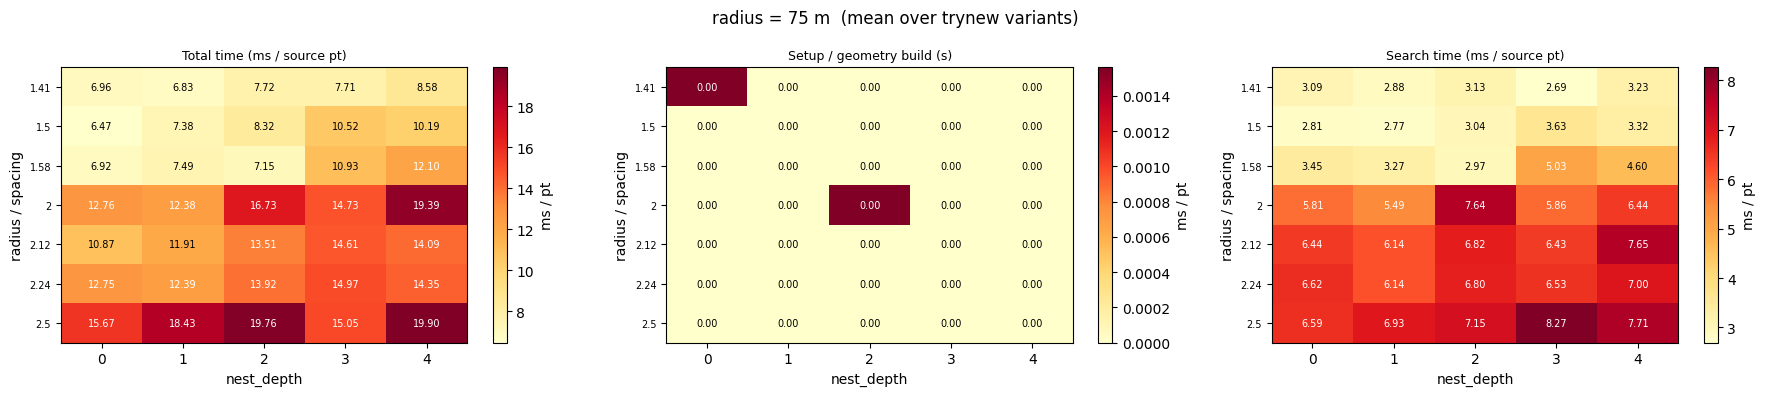

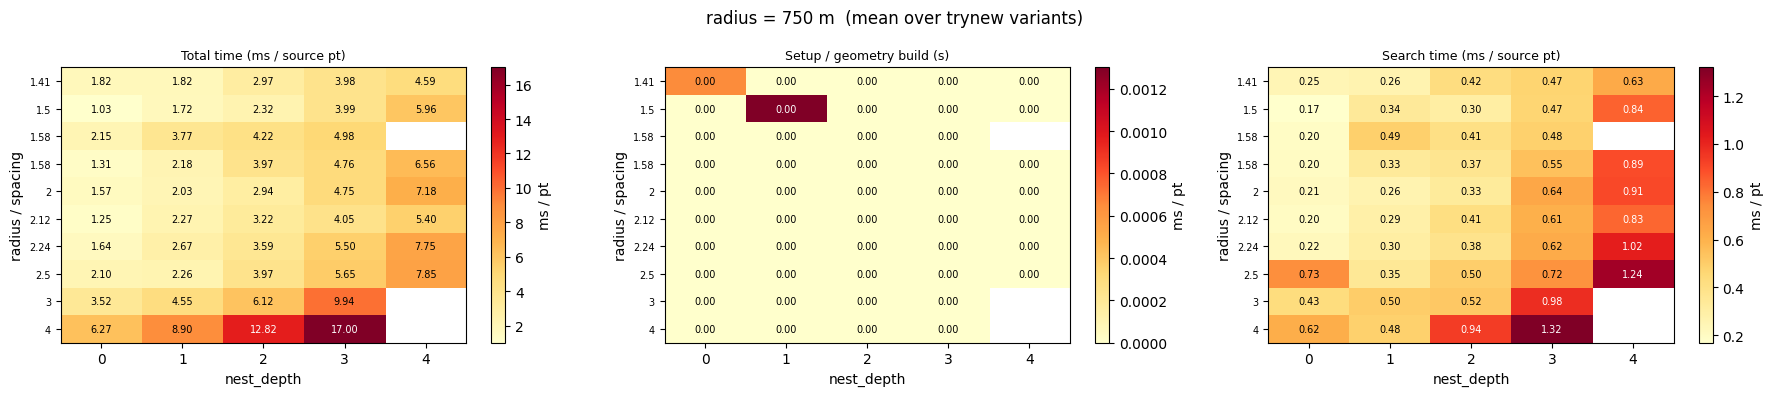

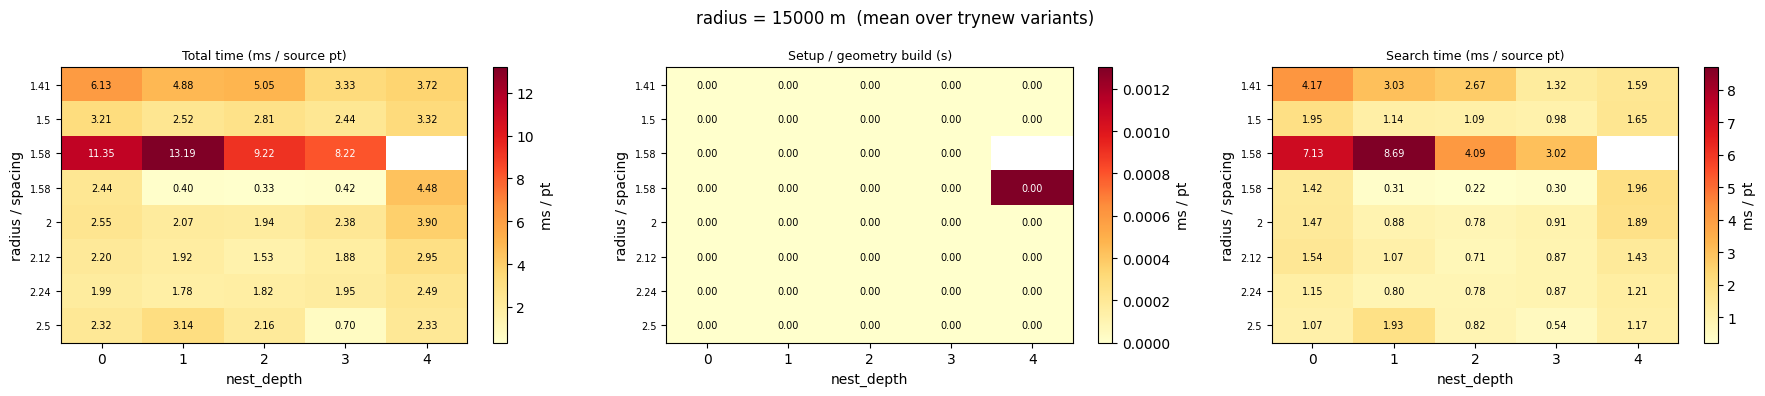


Mean ms/pt by trynew:
        total_ms_per_pt  setup_ms_per_pt  search_ms_per_pt
trynew                                                    
0                 5.871            0.001             1.980
1                 5.668            0.000             2.091


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# derived per-point metrics
df["total_ms_per_pt"]  = df["total_cpu_s"] / df["n_source"] * 1000
df["setup_ms_per_pt"]  = df.get("func_build_disk_region_lookups", 0)/ df["n_source"] * 1000
df["search_ms_per_pt"] = df.get("func_search_and_aggregate", 0) / df["n_source"] * 1000

VARIANTS = [
    ("total_ms_per_pt",  "Total time (ms / source pt)"),
    ("setup_ms_per_pt",  "Setup / geometry build (s)"),
    ("search_ms_per_pt", "Search time (ms / source pt)"),
]

for r in sorted(df["radius"].unique()):
    sub = df[(df["radius"] == r) & (df["radius_over_spacing"] <= 4) & (df["radius_over_spacing"] >= 1.4)]
    if sub.empty:
        continue

    fig, axes = plt.subplots(1, 3, figsize=(18, 4))
    fig.suptitle(f"radius = {r} m  (mean over trynew variants)", fontsize=12)

    for ax, (metric, title) in zip(axes, VARIANTS):
        piv = (
            sub.groupby(["radius_over_spacing", "nest_depth"])[metric]
            .mean()
            .unstack("nest_depth")
        )
        vals = piv.values.astype(float)
        im = ax.imshow(vals, aspect="auto", cmap="YlOrRd", origin="upper")
        ax.set_xticks(range(len(piv.columns)))
        ax.set_xticklabels(piv.columns)
        ax.set_yticks(range(len(piv.index)))
        ax.set_yticklabels([f"{v:.3g}" for v in piv.index], fontsize=7)
        ax.set_xlabel("nest_depth")
        ax.set_ylabel("radius / spacing")
        ax.set_title(title, fontsize=9)
        plt.colorbar(im, ax=ax, label="ms / pt")
        vmax = np.nanmax(vals)
        for ri in range(vals.shape[0]):
            for ci in range(vals.shape[1]):
                v = vals[ri, ci]
                if not np.isnan(v):
                    ax.text(ci, ri, f"{v:.2f}", ha="center", va="center",
                            fontsize=7, color="white" if v > vmax * 0.6 else "black")

    plt.tight_layout()
    plt.show()

# trynew comparison
if "trynew" in df.columns:
    print("\nMean ms/pt by trynew:")
    print(df.groupby("trynew")[["total_ms_per_pt", "setup_ms_per_pt", "search_ms_per_pt"]]
          .mean().round(3).to_string())

In [ ]:
df

,scenario_id,timestamp,machine_id,machine_hostname,machine_os,machine_os_version,machine_cpu,machine_cpu_count,machine_ram_gb,machine_python,...,spacing_ratio,search_cpu_s,aggregate_cpu_s,func_build_grid,log_cost,log_n,log_ros,total_ms_per_pt,setup_ms_per_pt,search_ms_per_pt
0,1b309a2d1e,2026-06-13T22:54:00,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,18.435039,NaN,NaN,2.914253,7.600902,0.458145,9.217520,0.0,4.093750
1,d99ac1b88b,2026-06-15T02:33:57,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,0.812472,NaN,NaN,-0.207674,7.600902,0.405465,0.406236,0.0,0.109375
2,0392e7e09e,2026-06-14T22:10:31,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,7.406170,NaN,NaN,2.002313,7.600902,0.458145,3.703085,0.0,3.117188
4,987d989157,2026-06-15T10:43:56,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,2.236068,0.640494,0.296875,0.0,-0.445516,7.600902,0.804719,0.320247,0.0,0.203125
6,776bae4990,2026-06-14T16:23:58,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,27.608928,NaN,NaN,3.318139,7.600902,0.405465,13.804464,0.0,1.375000
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1292,d99ac1b88b,2026-06-15T02:45:06,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,3.968583,NaN,NaN,1.378409,7.600902,0.752039,1.984291,0.0,0.882812
1293,987d989157,2026-06-15T10:28:50,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,1.414214,0.703013,0.343750,0.0,-0.352381,7.600902,0.346574,0.351506,0.0,0.203125
1294,035c4c0634,2026-06-15T00:26:37,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,NaN,9.328072,NaN,NaN,2.233028,7.600902,0.405465,4.664036,0.0,2.789062
1295,0392e7e09e,2026-06-15T11:16:02,0114fc15,DESKTOP-VK56MSH,Windows,10.0.26200,"Intel64 Family 6 Model 142 Stepping 12, Genuin...",8,15.8,3.13.9,...,1.414214,11.828045,0.828125,0.0,2.470473,7.600902,0.346574,5.914023,0.0,2.570312


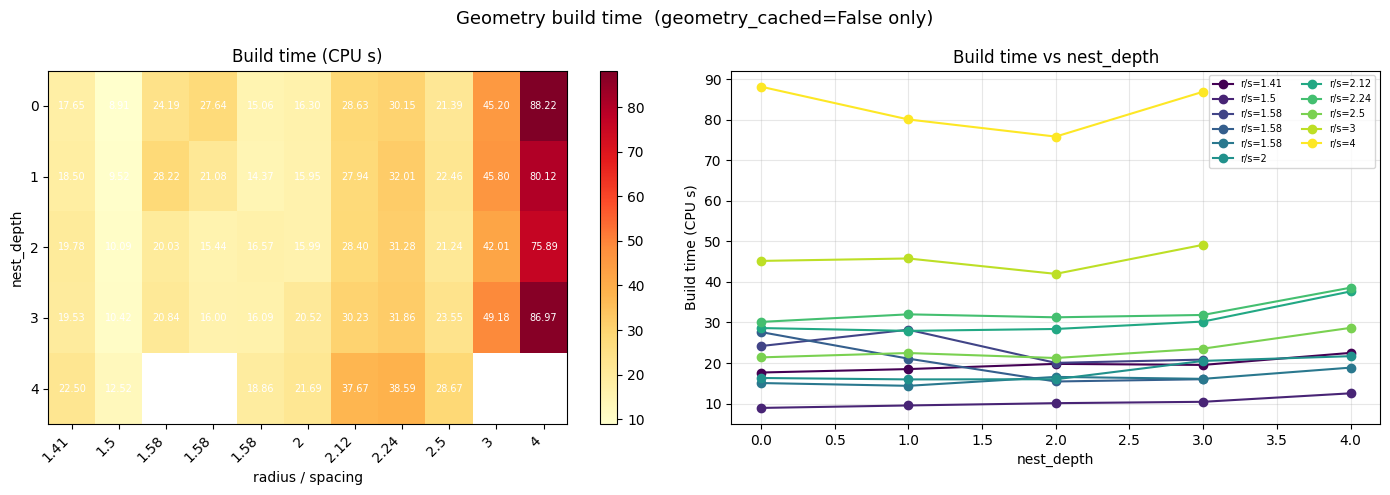

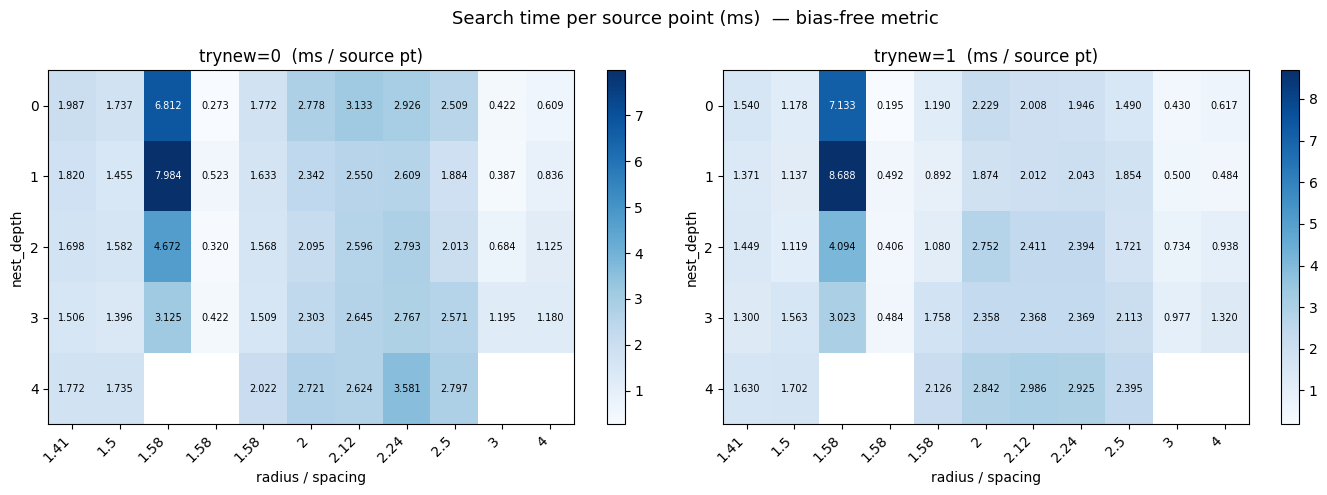

In [ ]:
import importlib.util, sys
spec = importlib.util.spec_from_file_location("perf_analysis", "perf_analysis.py")
pa = importlib.util.module_from_spec(spec)
spec.loader.exec_module(pa)
df = pa.load_results()
sub = df[(df["radius_over_spacing"] <= 4) & (df["radius_over_spacing"] >= 1.4)]
pa.plot_build_time(sub)
pa.plot_search_time(sub)

In [ ]:
# Cell 1 — imports & geometry extractor
import sys, time, math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, "Z:/Algorithm/PL_python/AABPL-toolkit-python")
from aabpl.radius_search.disk_region_geometry import build_disk_region_lookups

def compute_static_stats(r_over_s: float, nest_depth: int) -> dict:
    """
    Build the disk region geometry for a given r/spacing ratio and nest_depth,
    then extract static geometric properties. No point data required.
    """
    t0 = time.perf_counter()
    (_, _, _, _, id_to_regions, _, sh_cntd, sh_ovlpd, lookups
     ) = build_disk_region_lookups(
        grid=None, grid_spacing=1, r=r_over_s,
        nest_depth=nest_depth, silent=True,
    )
    build_s = time.perf_counter() - t0

    def cell_area(cells):
        return sum(2 ** (-2 * lvl) for lvl, _ in cells)

    circle_area = math.pi * r_over_s ** 2

    # per-region accumulators (weighted by region area)
    total_area = 0.0
    w_cntd_count = w_ovlpd_count = 0.0
    w_cntd_area  = w_ovlpd_area  = 0.0
    mean_cntd_count = mean_ovlpd_count = 0.0
    mean_cntd_area  = mean_ovlpd_area  = 0.0
    n_reg = len(id_to_regions)

    dc = lookups["region_id_to_distinct_cntd_cells"]
    do_ = lookups["region_id_to_distinct_ovlpd_cells"]

    for reg_id, reg in id_to_regions.items():
        reg_area = reg.calc_area()
        total_area += reg_area
        cc = len(dc[reg_id]);   ca = cell_area(dc[reg_id])
        oc = len(do_[reg_id]);  oa = cell_area(do_[reg_id])
        mean_cntd_count  += cc;  mean_ovlpd_count  += oc
        mean_cntd_area   += ca;  mean_ovlpd_area   += oa
        w_cntd_count  += cc * reg_area;  w_ovlpd_count  += oc * reg_area
        w_cntd_area   += ca * reg_area;  w_ovlpd_area   += oa * reg_area

    if n_reg:
        mean_cntd_count /= n_reg;  mean_ovlpd_count /= n_reg
        mean_cntd_area  /= n_reg;  mean_ovlpd_area  /= n_reg
    if total_area:
        w_cntd_count /= total_area;  w_ovlpd_count /= total_area
        w_cntd_area  /= total_area;  w_ovlpd_area  /= total_area

    # add shared cells
    sh_cc = len(sh_cntd); sh_ca = cell_area(sh_cntd)
    sh_oc = len(sh_ovlpd); sh_oa = cell_area(sh_ovlpd)

    return dict(
        r_over_s=r_over_s, nest_depth=nest_depth,
        n_regions=n_reg,
        # mean across regions (unweighted)
        mean_cntd_count =mean_cntd_count  + sh_cc,
        mean_ovlpd_count=mean_ovlpd_count + sh_oc,
        mean_cntd_area  =mean_cntd_area   + sh_ca,
        mean_ovlpd_area =mean_ovlpd_area  + sh_oa,
        # weighted by region area
        w_cntd_count =w_cntd_count  + sh_ca,
        w_ovlpd_count=w_ovlpd_count + sh_oa,
        w_cntd_area  =w_cntd_area   + sh_ca,
        w_ovlpd_area =w_ovlpd_area  + sh_oa,
        # share of circle area (spacing² units, geometry-only)
        share_cntd =( mean_cntd_area  + sh_ca) / circle_area if circle_area else 0,
        share_ovlpd=( mean_ovlpd_area + sh_oa) / circle_area if circle_area else 0,
        build_s=build_s,
    )

In [ ]:
# Cell 2 — compute for target ratios × nest depths
R_OVER_S  = [1.5, 1.58113883, 2.0, 2.5, 3.0, 4.0]
NEST_DEPTHS = [0, 1, 2, 3, 4]

rows = []
for rs in R_OVER_S:
    for nd in NEST_DEPTHS:
        print(f"  r/s={rs:.4g}  nd={nd} ...", end=" ", flush=True)
        row = compute_static_stats(rs, nd)
        rows.append(row)
        print(f"build={row['build_s']:.1f}s  "
              f"cntd={row['mean_cntd_count']:.1f}  ovlpd={row['mean_ovlpd_count']:.1f}")

geo = pd.DataFrame(rows)
geo

  r/s=1.5  nd=0 ... 

ValueError: too many values to unpack (expected 9)

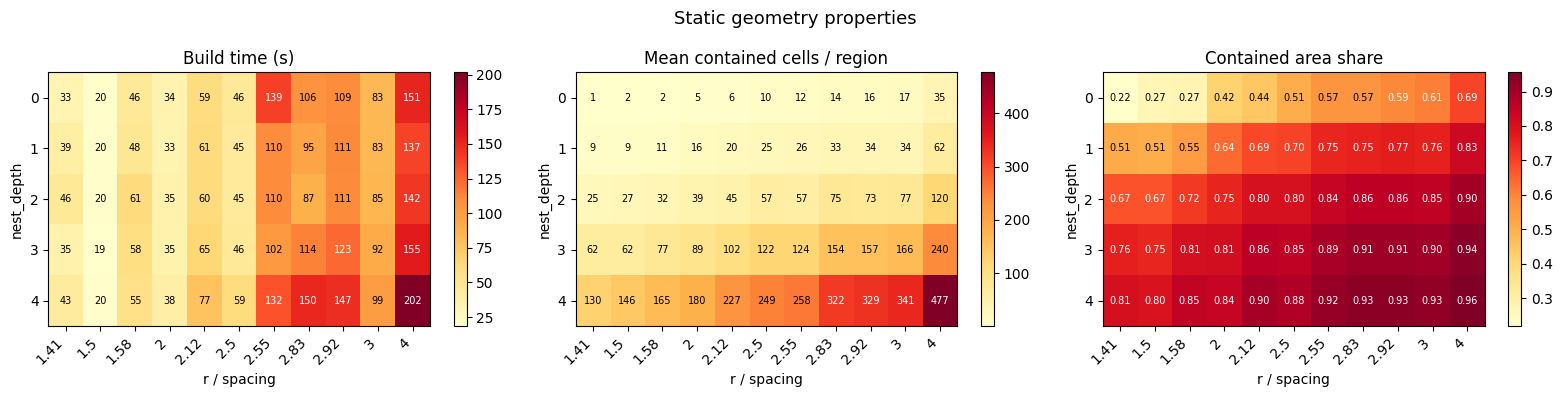

In [ ]:
# Cell 3 — build time heatmap
pivot_build = geo.pivot(index="nest_depth", columns="r_over_s", values="build_s")

fig, axes = plt.subplots(1, 3, figsize=(16, 4))
fig.suptitle("Static geometry properties", fontsize=13)

for ax, col, title in zip(axes,
        ["build_s",       "mean_cntd_count",  "share_cntd"],
        ["Build time (s)", "Mean contained cells / region", "Contained area share"]):
    piv = geo.pivot(index="nest_depth", columns="r_over_s", values=col)
    im = ax.imshow(piv.values, aspect="auto", cmap="YlOrRd")
    ax.set_xticks(range(len(piv.columns)))
    ax.set_xticklabels([f"{v:.3g}" for v in piv.columns], rotation=45, ha="right")
    ax.set_yticks(range(len(piv.index)))
    ax.set_yticklabels(piv.index)
    ax.set_xlabel("r / spacing")
    ax.set_ylabel("nest_depth")
    ax.set_title(title)
    plt.colorbar(im, ax=ax)
    vmax = np.nanmax(piv.values)
    for r in range(len(piv.index)):
        for c in range(len(piv.columns)):
            v = piv.values[r, c]
            if not np.isnan(v):
                fmt = f"{v:.0f}" if col in ("build_s","mean_cntd_count") else f"{v:.2f}"
                ax.text(c, r, fmt, ha="center", va="center", fontsize=7,
                        color="white" if v > vmax * 0.6 else "black")

plt.tight_layout()
plt.show()

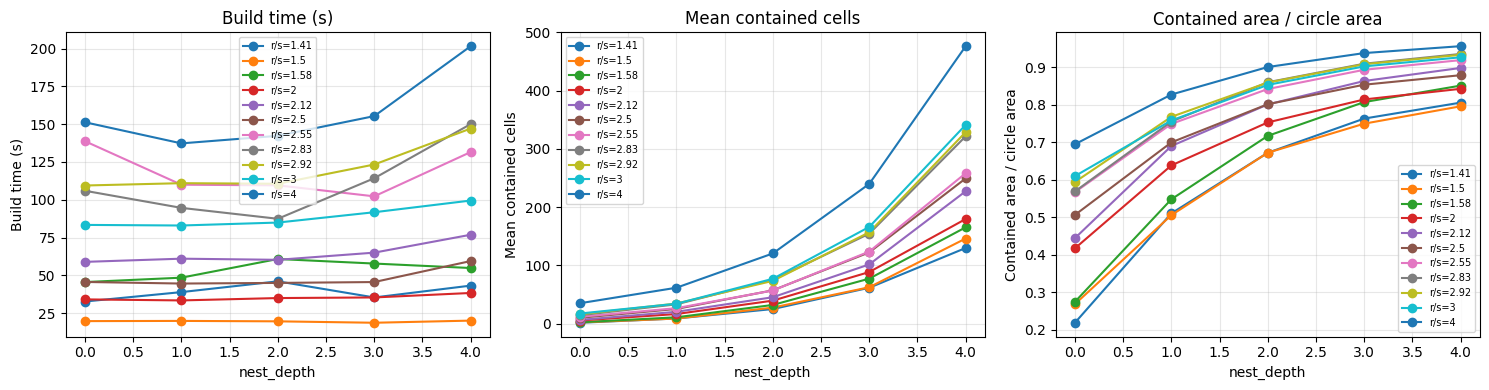

In [ ]:
# Cell 4 — build time & cell counts vs nest_depth, one line per r/s
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

for ax, col, ylabel in zip(axes,
        ["build_s", "mean_cntd_count", "share_cntd"],
        ["Build time (s)", "Mean contained cells", "Contained area / circle area"]):
    for rs, sub in geo.groupby("r_over_s"):
        ax.plot(sub["nest_depth"], sub[col], marker="o", label=f"r/s={rs:.3g}")
    ax.set_xlabel("nest_depth")
    ax.set_ylabel(ylabel)
    ax.set_title(ylabel)
    ax.legend(fontsize=7)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

---
## Prediction Models

Fit interpretable log-linear formulas for each timing component:

| Component | Target column | Data |
|---|---|---|
| Geometry build | `func_build_disk_region_lookups` | uncached runs only |
| Search | `search_cpu_s` | all runs |
| Aggregation | `aggregate_cpu_s` | all runs |
| **Total** | sum of above | — |

Formula form: `time = exp(intercept) × (r/s)^a × n^b × exp(c·nd) × …`

In [ ]:
# ── Load & prepare ────────────────────────────────────────────────────────────
import sys; [sys.modules.pop(m) for m in list(sys.modules.keys()) if m.startswith('aabpl')]
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
from aabpl.testing.perf_benchmark import load_results
import aabpl.config as _aabpl_config

df_all = load_results(PERF_FOLDER)
print(f"Total runs loaded: {len(df_all)}")
df_all["pts_per_circle"] = df_all["n_target"] / df_all["scen_spatial_area"] * np.pi * df_all["radius"]**2
df_all["n_grid_cells"] = (
    df_all["scen_spatial_width"]  / (df_all["radius"] / df_all["radius_over_spacing"])
    * df_all["scen_spatial_height"] / (df_all["radius"] / df_all["radius_over_spacing"])
    * (4 ** df_all["nest_depth"])
)

# ── Compute total_area / circle_area from geometry cache ───────────────────
def _area_ratio(r_over_s, nest_depth):
    import math
    key = (round(r_over_s, 8), int(nest_depth), False)
    cached = _aabpl_config.disk_region_cache.get(key)
    if cached is None:
        return float("nan")
    total_area = sum(cached["region_id_to_area"].values()) or 1.0
    circle_area = math.pi * r_over_s ** 2
    return total_area / circle_area

area_ratio_map = {
    (ros, nd): _area_ratio(ros, nd)
    for ros, nd in df_all[["radius_over_spacing", "nest_depth"]].drop_duplicates().itertuples(index=False)
}
df_all["area_ratio"] = df_all.apply(
    lambda row: area_ratio_map.get((row["radius_over_spacing"], row["nest_depth"]), float("nan")),
    axis=1,
)
print(f"area_ratio computed for {df_all['area_ratio'].notna().sum()}/{len(df_all)} rows")

df_uncached = df_all[df_all["geometry_cached"] == False].copy()
df_cached   = df_all[df_all["geometry_cached"] == True].copy()
print(f"  uncached: {len(df_uncached)}  cached: {len(df_cached)}")
print(f"  aggregate_cpu_s available: {df_all['aggregate_cpu_s'].notna().sum()} rows")


In [ ]:
from sklearn.linear_model import LassoCV, LinearRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import r2_score

# ── Shared helpers ─────────────────────────────────────────────────────────
FEAT_NAMES = ["log(r/s)", "nd", "nd²", "log(1+4^nd)", "log(n_grid_cells)",
              "log(r/s)×nd", "log(gc)×nd", "log(n_tgt)", "log(n_src)",
              "log(ppc)", "log(skew)", "log(ppc)×log(r/s)", "log(area_ratio)",
              "log(n_regions)", "log(mean_cntd)", "log(mean_ovlpd)"]

def make_X(df, include_trynew=False):
    ros = df["radius_over_spacing"].values
    nd  = df["nest_depth"].values
    gc  = df["n_grid_cells"].values
    ppc = df["pts_per_circle"].values
    cols = [np.log(ros), nd, nd**2, np.log1p(4.0**nd), np.log(gc),
            np.log(ros)*nd, np.log(gc)*nd,
            np.log(df["n_target"].values), np.log(df["n_source"].values),
            np.log(ppc), np.log(df["scen_density_skewness_max_to_mean"].values),
            np.log(ppc)*np.log(ros), np.log(df["area_ratio"].values),
            np.log(df["n_regions"].values), np.log(df["mean_cntd_count"].values),
            np.log(df["mean_ovlpd_count"].values)]
    names = FEAT_NAMES.copy()
    if include_trynew:
        cols.append(df["trynew"].values.astype(float))
        names.append("trynew")
    return np.column_stack(cols), names

def lasso_then_ols(X, y, names, label):
    """LASSO selects variables; OLS on raw selected features gives interpretable exponents."""
    scaler = StandardScaler()
    m_lasso = LassoCV(cv=5, max_iter=10000).fit(scaler.fit_transform(X), y)
    mask = m_lasso.coef_ != 0
    selected = [n for n, keep in zip(names, mask) if keep]

    X_sel = X[:, mask]
    m_ols = LinearRegression().fit(X_sel, y)
    coefs = pd.Series(m_ols.coef_, index=selected)

    print(f"\n── {label}")
    print(f"   LASSO R²={m_lasso.score(scaler.transform(X), y):.3f}  "
          f"α={m_lasso.alpha_:.5f}  selected {mask.sum()}/{len(names)}: {selected}")
    print(f"   OLS   R²={m_ols.score(X_sel, y):.3f}  "
          f"intercept={m_ols.intercept_:.4f}  → exp={np.exp(m_ols.intercept_):.5f}")
    print("   Formula:")
    for name, coef in coefs.items():
        if "×" not in name and name.startswith("log("):
            print(f"     × {name[4:-1]}^{coef:.3f}")
        else:
            print(f"     × exp({coef:.3f}·{name})")

    return mask, m_ols

def lasso_predict(df, mask, m_ols, include_trynew=False):
    X, _ = make_X(df, include_trynew)
    return np.exp(m_ols.predict(X[:, mask]))

# ── Data prep ──────────────────────────────────────────────────────────────
BASE_COLS = ["radius_over_spacing", "nest_depth", "n_grid_cells",
             "n_target", "n_source", "pts_per_circle",
             "scen_density_skewness_max_to_mean", "area_ratio",
             "n_regions", "mean_cntd_count", "mean_ovlpd_count"]

df_all["search_cpu_s_adj"] = np.where(
    df_all["geometry_cached"],
    df_all["search_cpu_s"],
    df_all["search_cpu_s"] - df_all["func_build_disk_region_lookups"].fillna(0)
)

geo = (df_all[df_all["geometry_cached"] == False]
       .dropna(subset=BASE_COLS + ["func_build_disk_region_lookups"])
       .pipe(lambda d: d[d["func_build_disk_region_lookups"] > 0])
       .groupby(["radius_over_spacing", "nest_depth"])
       .agg(func_build_disk_region_lookups=("func_build_disk_region_lookups", "min"),
            **{c: (c, "first") for c in BASE_COLS if c not in ["radius_over_spacing", "nest_depth"]})
       .reset_index())

srch = (df_all.dropna(subset=BASE_COLS + ["trynew", "search_cpu_s_adj"])
        .pipe(lambda d: d[d["search_cpu_s_adj"] > 0]).copy())
srch["_y"] = srch["search_cpu_s_adj"] / srch["n_source"]

agg = (df_all.dropna(subset=BASE_COLS + ["aggregate_cpu_s"])
       .pipe(lambda d: d[d["aggregate_cpu_s"] > 0]).copy())
agg["_y"] = agg["aggregate_cpu_s"] / agg["n_source"]

print(f"geo: {len(geo)} rows  srch: {len(srch)} rows  agg: {len(agg)} rows")

# ── Fit models ─────────────────────────────────────────────────────────────
X_geo,  names_geo  = make_X(geo)
X_srch, names_srch = make_X(srch, include_trynew=True)
X_agg,  names_agg  = make_X(agg)

mask_geo,  m_geo  = lasso_then_ols(X_geo,  np.log(geo["func_build_disk_region_lookups"]), names_geo,  "Geometry (absolute s)")
mask_srch, m_srch = lasso_then_ols(X_srch, np.log(srch["_y"]),                            names_srch, "Search (per source pt)")
mask_agg,  m_agg  = lasso_then_ols(X_agg,  np.log(agg["_y"]),                             names_agg,  "Aggregation (per source pt)")

# ── Predict functions ───────────────────────────────────────────────────────
def predict_geometry(df):  return lasso_predict(df, mask_geo,  m_geo)
def predict_search(df):    return lasso_predict(df, mask_srch, m_srch, include_trynew=True) * df["n_source"]
def predict_aggregate(df): return lasso_predict(df, mask_agg,  m_agg) * df["n_source"]


In [ ]:
# ── 4. Total time = geometry + search + aggregation ──────────────────────────
# geometry_cached runs: geometry cost = 0 (already built).
# Use df_all; predict geometry only for uncached runs.

eval_df = df_all[[
    "radius_over_spacing", "nest_depth", "trynew",
    "n_source", "n_target", "geometry_cached", "total_cpu_s",
    "pts_per_circle", "scen_density_skewness_max_to_mean", "n_grid_cells",
]].dropna().copy()

eval_df["pred_geometry"] = np.where(
    eval_df["geometry_cached"],
    0.0,
    predict_geometry(eval_df),
)
eval_df["pred_search"]    = predict_search(eval_df)
eval_df["pred_aggregate"] = predict_aggregate(eval_df)
eval_df["pred_total"]     = eval_df["pred_geometry"] + eval_df["pred_search"] + eval_df["pred_aggregate"]

mae  = (eval_df["pred_total"] - eval_df["total_cpu_s"]).abs().mean()
r2   = r2_score(eval_df["total_cpu_s"], eval_df["pred_total"])
print(f"Combined total — MAE: {mae:.3f}s   R²: {r2:.3f}   n={len(eval_df)}")

# ── Diagnostic plots ─────────────────────────────────────────────────────────
fig, axes = plt.subplots(1, 4, figsize=(20, 4))
fig.suptitle("Actual vs Predicted (log scale)", fontsize=12)

panels = [
    ("func_build_disk_region_lookups", "pred_geometry", "Geometry build (uncached)", df_uncached),
    ("search_cpu_s",                   "pred_search",    "Search",                   df_all),
    ("aggregate_cpu_s",                "pred_aggregate", "Aggregation",              df_all),
    ("total_cpu_s",                    "pred_total",     "Total",                    eval_df),
]

for ax, (actual_col, pred_col, title, src) in zip(axes, panels):
    merged = src.copy()
    if pred_col not in merged.columns:
        merged[pred_col] = (
            predict_geometry(merged) if pred_col == "pred_geometry" else
            predict_search(merged)   if pred_col == "pred_search"   else
            predict_aggregate(merged)
        )
    sub = merged[[actual_col, pred_col]].dropna()
    sub = sub[(sub[actual_col] > 0) & (sub[pred_col] > 0)]
    ax.scatter(sub[actual_col], sub[pred_col], alpha=0.35, s=12)
    lims = [min(sub[actual_col].min(), sub[pred_col].min()),
            max(sub[actual_col].max(), sub[pred_col].max())]
    ax.plot(lims, lims, "r--", lw=1)
    ax.set_xscale("log"); ax.set_yscale("log")
    ax.set_xlabel("actual (s)"); ax.set_ylabel("predicted (s)")
    r2_sub = r2_score(np.log(sub[actual_col]), np.log(sub[pred_col]))
    ax.set_title(f"{title}\nR²(log)={r2_sub:.3f}  n={len(sub)}", fontsize=9)

plt.tight_layout()
plt.show()

In [ ]:
# ── Optimal config recommendation ─────────────────────────────────────────
# Given scenario parameters, predict total CPU time for every (sr, nd) candidate
# and return them ranked best-first.
#
# geometry_cached=True  → assume geometry already in cache (repeated calls same r/s)
# geometry_cached=False → include geometry build cost (first call for this r/s)

from aabpl.testing.perf_benchmark import compute_static_stats

def recommend_config(
    n_source: int,
    n_target: int,
    radius: float,
    spacing_ratios: list,
    nest_depths: list,
    scen_spatial_width: float,
    scen_spatial_height: float,
    scen_spatial_area: float,
    scen_density_skewness_max_to_mean: float,
    geometry_cached: bool = False,
) -> pd.DataFrame:
    """Return candidate (spacing_ratio, nest_depth) configs ranked by predicted total CPU time."""

    rows = []
    for sr in spacing_ratios:
        spacing = radius / sr
        n_gc_base = scen_spatial_width / spacing * scen_spatial_height / spacing
        pts_per_circle = n_target / scen_spatial_area * np.pi * radius ** 2
        circle_to_world = scen_spatial_width * scen_spatial_height / (np.pi * radius ** 2)

        for nd in nest_depths:
            # ensure geometry is in cache so we can look up n_regions etc.
            stats = compute_static_stats(sr, nd)

            rows.append({
                "radius_over_spacing":              sr,
                "nest_depth":                       nd,
                "n_source":                         n_source,
                "n_target":                         n_target,
                "n_grid_cells":                     n_gc_base * (4 ** nd),
                "pts_per_circle":                   pts_per_circle,
                "scen_density_skewness_max_to_mean": scen_density_skewness_max_to_mean,
                "circle_to_world":                  circle_to_world,
                "area_ratio":                       stats.get("area_ratio", float("nan")),
                "n_regions":                        stats.get("n_regions",  float("nan")),
                "mean_cntd_count":                  stats.get("mean_cntd_count", float("nan")),
                "mean_ovlpd_count":                 stats.get("mean_ovlpd_count", float("nan")),
                "trynew":                           1,
            })

    cand = pd.DataFrame(rows)
    cand["pred_geometry"]  = np.where(geometry_cached, 0.0, predict_geometry(cand))
    cand["pred_search"]    = predict_search(cand)
    cand["pred_aggregate"] = predict_aggregate(cand)
    cand["pred_total"]     = cand["pred_geometry"] + cand["pred_search"] + cand["pred_aggregate"]

    return (
        cand[["radius_over_spacing", "nest_depth",
              "pred_geometry", "pred_search", "pred_aggregate", "pred_total"]]
        .sort_values("pred_total")
        .reset_index(drop=True)
    )


# ── Example usage ──────────────────────────────────────────────────────────
_ex = df_all.iloc[0]
rec = recommend_config(
    n_source   = int(_ex["n_source"]),
    n_target   = int(_ex["n_target"]),
    radius     = float(_ex["radius"]),
    spacing_ratios = sorted(df_all["radius_over_spacing"].dropna().unique()),
    nest_depths    = sorted(df_all["nest_depth"].dropna().astype(int).unique()),
    scen_spatial_width  = float(_ex["scen_spatial_width"]),
    scen_spatial_height = float(_ex["scen_spatial_height"]),
    scen_spatial_area   = float(_ex["scen_spatial_area"]),
    scen_density_skewness_max_to_mean = float(_ex["scen_density_skewness_max_to_mean"]),
    geometry_cached = False,
)
print(f"Best config: sr={rec.iloc[0]['radius_over_spacing']:.3f}  nd={int(rec.iloc[0]['nest_depth'])}"
      f"  pred_total={rec.iloc[0]['pred_total']:.3f}s")
rec.head(10)
